In [7]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict


In [ ]:
class MyState(TypedDict):
    num1 : float
    num2 : float
    sum : float
    is_even : bool
    multiply_sum : float

In [15]:
# we define the node

def calculate_sum(state:MyState) -> MyState:

    num1 = state['num1']
    num2 = state['num2']
    
    state['sum'] = num1 + num2
    
    return state

In [24]:

# Another node
def is_even(state:MyState)->MyState:

    if(state['sum'] %2 == 0):
        state['is_even'] = True
    else:
        state['is_even'] = False
    return state

def if_is_even(state:MyState)->MyState:
    state['multiply_sum'] = state['sum'] *2 
    return state





In [23]:
# routing 

def router(state:MyState):
    if state['is_even']:
        return "continue"
    else:
        return "end"

In [26]:
# graph workflow
# start 
#  |
# calculate_sum
#  |
# end

#define the graph

graph = StateGraph(MyState)


# adding node to the graph 

graph.add_node('calculate_sum',calculate_sum)
graph.add_node('is_even',is_even)
graph.add_node('if_is_even',if_is_even)

# adding edges 

graph.add_edge(START,'calculate_sum')
graph.add_edge('calculate_sum','is_even')
graph.add_conditional_edges(
    "is_even",
    router,
    {
        "continue":"if_is_even",
        "end":END
    },
)
graph.add_edge("if_is_even",END)

# compiles the graph 
workflow = graph.compile()




In [27]:
#execute the graph
final_state = workflow.invoke({'num1':4,'num2':3})

print(final_state)

{'num1': 4, 'num2': 3, 'sum': 7, 'is_even': False}


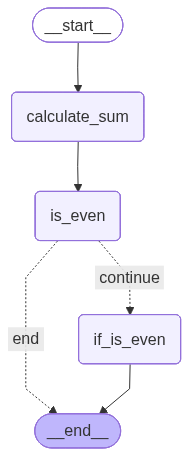

In [28]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())